<a href="https://colab.research.google.com/github/kkeshavsharma/TITANIC/blob/main/adv_titanic_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Importing Libraries**

In [1]:
#kaggle titanic dataset is used in this project you can download it from kaggle website.
#download data from here = "https://www.kaggle.com/competitions/titanic/data"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import sqlite3
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

## **Loading Data**

In [2]:
df = pd.read_csv("train.csv")
df.head(30).style.background_gradient(cmap="YlOrRd")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,nan,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.283300,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,nan,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.100000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.050000,nan,S
5,6,0,3,"Moran, Mr. James",male,nan,0,0,330877,8.458300,nan,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.862500,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.075000,nan,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.133300,nan,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.070800,nan,C


ASCII conversion

In [3]:
df.columns = df.columns.map(lambda x: x.encode ("ascii", "ignore").decode("ascii"))

In [4]:
df.shape

(891, 12)

In [5]:
df.isna().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Data Analysis**

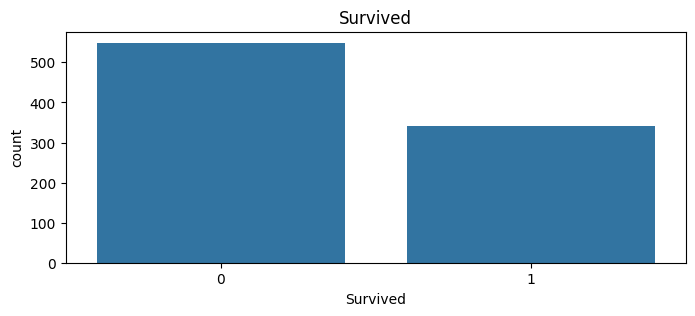

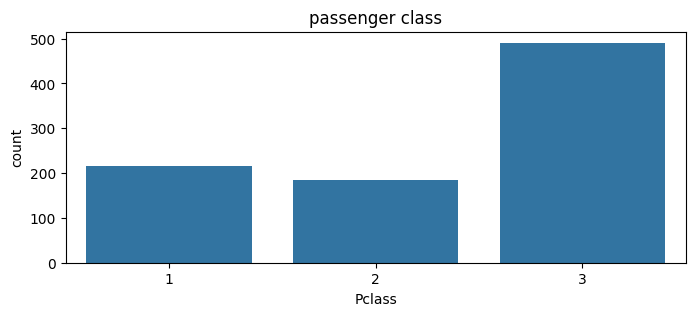

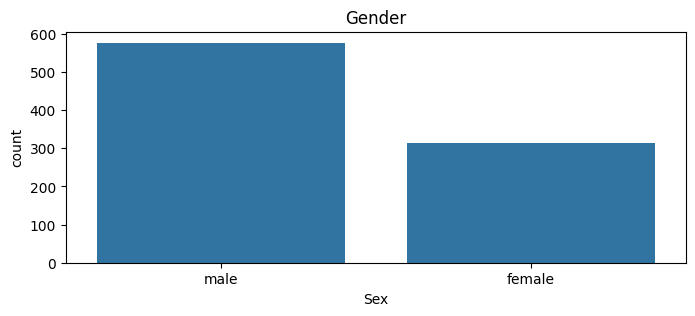

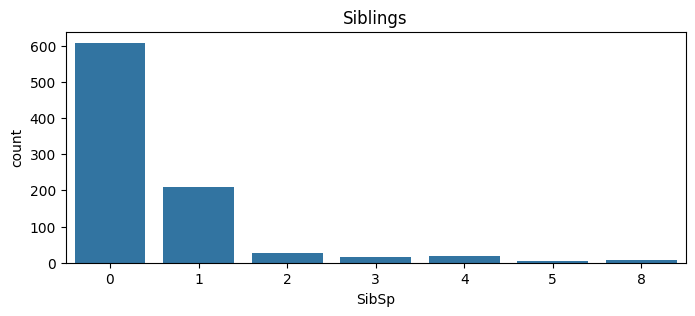

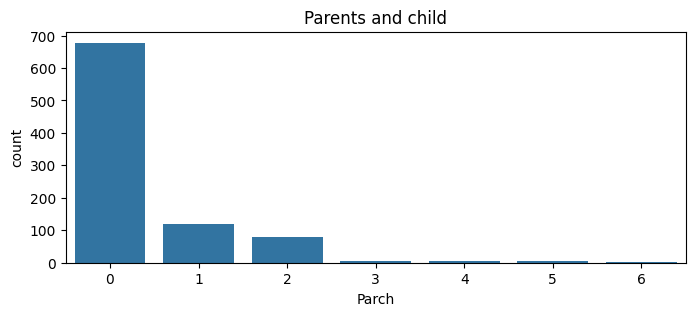

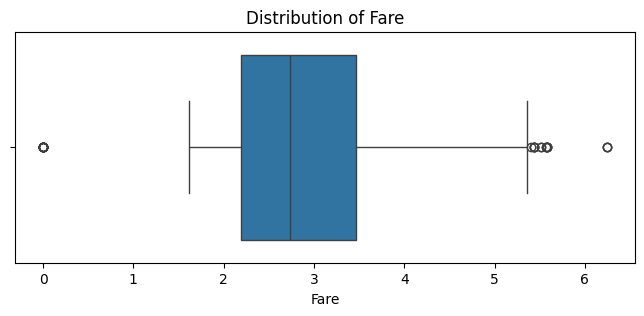

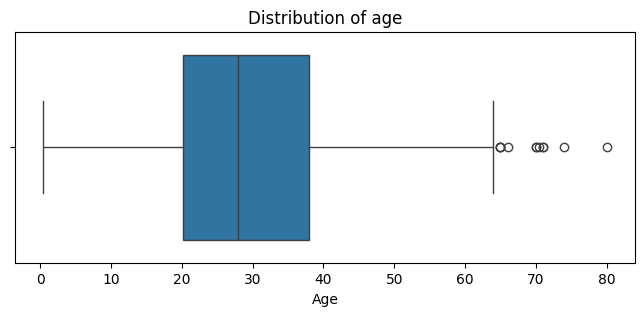

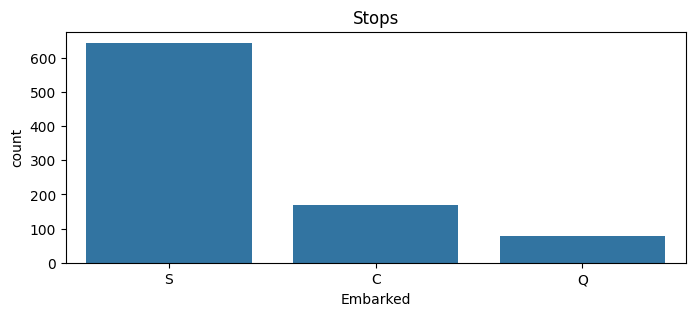

In [6]:
plt.figure(figsize=(8,3))
sns.countplot(x=df["Survived"])
plt.title("Survived")
plt.show()

plt.figure(figsize=(8,3))
sns.countplot(x=df["Pclass"])
plt.title("passenger class")
plt.show()


plt.figure(figsize=(8,3))
sns.countplot(x=df["Sex"])
plt.title("Gender")
plt.show()


plt.figure(figsize=(8,3))
sns.countplot(x=df["SibSp"])
plt.title("Siblings")
plt.show()


plt.figure(figsize=(8,3))
sns.countplot(x=df["Parch"])
plt.title("Parents and child")
plt.show()


plt.figure(figsize=(8,3))
sns.boxplot(x=np.log1p(df["Fare"]))
plt.title("Distribution of Fare")
plt.show()


plt.figure(figsize=(8,3))
sns.boxplot(x=df["Age"])
plt.title("Distribution of age")
plt.show()


plt.figure(figsize=(8,3))
sns.countplot(x=df["Embarked"])
plt.title("Stops")
plt.show()

# **Data Cleaning**

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df = df.drop("PassengerId", axis = 1)
df["Sex"] = df["Sex"].astype(str).str.strip().str.lower()
df["Sex"]= df["Sex"].map({"male":1, "female":0})
df["Embarked"] = df["Embarked"].str.strip().str.upper()
df["Embarked"]= df["Embarked"].map({"S":0, "Q":1, "C":2})
df["Title"] = df["Name"].str.extract(r",\s*([A-Za-z]+)\.")
df["Ticket"] = df["Ticket"].str.extract(r"(^[A-Za-z./]+)")
df["Cabin"] = df["Cabin"].str.extract(r"([A-Za-z./]+)")
df = df.drop("Name", axis =1)
le = LabelEncoder()
df["Title"] = le.fit_transform(df["Title"].astype(str))
df["Ticket"] = le.fit_transform(df["Ticket"].astype(str))
df["Cabin"] = le.fit_transform(df["Cabin"].astype(str))


df.head(30)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,0,3,1,22.0,1,0,3,7.2500,8,0.0,11
1,1,1,0,38.0,1,0,15,71.2833,2,2.0,12
2,1,3,0,26.0,0,0,33,7.9250,8,0.0,8
3,1,1,0,35.0,1,0,39,53.1000,2,0.0,12
4,0,3,1,35.0,0,0,39,8.0500,8,0.0,11
5,0,3,1,NaN,0,0,39,8.4583,8,1.0,11
6,0,1,1,54.0,0,0,39,51.8625,4,0.0,11
7,0,3,1,2.0,3,1,39,21.0750,8,0.0,7
8,1,3,0,27.0,0,2,39,11.1333,8,0.0,12
9,1,2,0,14.0,1,0,39,30.0708,8,2.0,12


In [9]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0
Embarked,2


train test split

In [10]:
train_df = df[df["Survived"].notna()]
test_df = df[df["Survived"].isna()]
test_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title


In [11]:
training_set = df[["Pclass","Sex","Age","SibSp","Parch","Ticket","Fare","Cabin","Embarked","Title"]]
x = training_set.loc[train_df.index]
y= df["Survived"]

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 50)


# **first take out test set then apply imputarion**

In [13]:
imputer = IterativeImputer()
x_train = pd.DataFrame(imputer.fit_transform(x_train), columns = x_train.columns)
x_test = pd.DataFrame(imputer.transform(x_test), columns = x_test.columns)
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,3.0,0.0,29.000000,0.0,4.0,39.0,21.075,8.0,0.0,12.0
1,3.0,1.0,29.687724,0.0,0.0,19.0,7.550,8.0,0.0,11.0
2,3.0,1.0,28.371886,0.0,0.0,39.0,7.750,8.0,1.0,11.0
3,2.0,0.0,4.000000,2.0,1.0,39.0,39.000,5.0,0.0,8.0
4,3.0,1.0,29.158149,0.0,0.0,39.0,8.050,8.0,0.0,11.0


Model fitting

In [14]:
scale_pos_weight = y_train.value_counts()[0]/y_train.value_counts()[1]
scale_pos_weight = scale_pos_weight

In [15]:
xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.3,
    colsample_bytree=1,
    gamma=0.9,
    min_child_weight=3,
    reg_alpha=3,
    reg_lambda=2,
    random_state= 43,
    scale_pos_weight = scale_pos_weight,
    objective='binary:logistic')
xgb.fit(x_train,y_train, eval_set=[(x_test, y_test)], verbose = False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.9, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
print(x_train.columns)
print(xgb.feature_importances_)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin',
       'Embarked', 'Title'],
      dtype='object')
[0.11392162 0.31728238 0.0595118  0.06702997 0.06067666 0.04993149
 0.06541009 0.11924589 0.05819466 0.08879536]


In [17]:
proba = xgb.predict_proba(x_train)


In [21]:
xgb.score(x_test,y_test)

0.8212290502793296

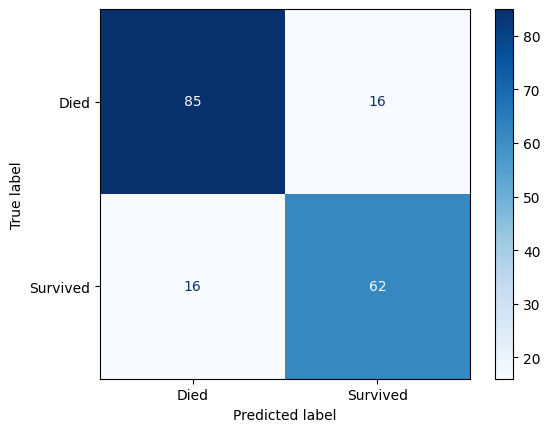

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = xgb.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Died", "Survived"]
)

disp.plot(cmap="Blues")
plt.show()

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[85 16]
 [16 62]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       101
           1       0.79      0.79      0.79        78

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179

